# Lecture 07 (B05): Automatic differentiation for DEQNs

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §2.7 (Automatic differentiation), §Appendix B (Matrix calculus)  
**Notebook role:** core  
**Author:** Simon Scheidegger  


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


In [ ]:
# Chapter-wide RUN_MODE budget helper -- maps RUN_MODE to a training budget.
_BUDGET = {
    "smoke":      201,    # ~10 s, sanity check only
    "teaching":  2001,    # ~1 min CPU, default for live class
    "production": 10001,  # ~5 min CPU, publication run
}
NUM_EPISODES = _BUDGET[RUN_MODE]
print(f"RUN_MODE={RUN_MODE!r}: NUM_EPISODES={NUM_EPISODES}")


# Deep Equilibrium Nets via Automatic Differentiation

## Notebook 2: replacing the FOC and envelope theorem with `tf.GradientTape`

### Purpose of the notebook
Notebooks **01** and **02** solve the Brock–Mirman (1972) growth model with [Deep Equilibrium Nets](https://onlinelibrary.wiley.com/doi/full/10.1111/iere.12575) (Azinovic et al., 2022). In both, the user does *two* derivations on paper before writing any code:

1. **First-order condition (FOC)** of the Bellman objective with respect to $K_{t+1}$.
2. **Envelope theorem** to eliminate the unknown derivative $V'(K_{t+1})$.

The resulting Euler equation is then hard-coded as the loss. If one changes the utility function (log $\to$ CRRA) or the production function (Cobb–Douglas $\to$ CES), the algebra has to be redone.

**This notebook removes both manual steps.** The user writes only the *period payoff* $\Pi(K_t, K_{t+1}) = u(C_t)$ as a single primitive function. TensorFlow's `tf.GradientTape` then computes both the FOC term and the envelope term as gradients of $\Pi$.

We solve the **same model as notebook 01** (deterministic, full depreciation, log utility) so that we can verify the autodiff loss against (i) the closed-form analytical policy and (ii) the hand-derived loss of notebook 01 — at machine precision.

### The model (recap of notebook 01)
The planner solves
$$\max_{\{C_t\}} \sum_{t=0}^{\infty} \beta^t \ln(C_t) \quad\text{s.t.}\quad K_{t+1} + C_t = Y_t + (1-\delta)K_t,\qquad Y_t = K_t^{\alpha}.$$
With full depreciation $\delta = 1$ this admits the analytical solution $K_{t+1} = \alpha\beta\,K_t^{\alpha}$.

Recursively,
$$V(K_t) = \max_{K_{t+1}} \;\underbrace{\ln(Y_t + (1-\delta)K_t - K_{t+1})}_{=\,\Pi(K_t,\,K_{t+1})} \;+\; \beta\, V(K_{t+1}).$$

### Why we no longer need pen-and-paper FOC + envelope
Define the **period payoff**
$$\Pi(K_{\text{in}},\,K_{\text{out}}) \;=\; u\!\big(\,Y(K_{\text{in}}) + (1-\delta)K_{\text{in}} - K_{\text{out}}\,\big),$$
where $K_{\text{in}}$ is the *state* (today's capital) and $K_{\text{out}}$ is the *choice* (tomorrow's capital). This is the *only primitive* the user writes.

> **Notation — what do $\partial_1\Pi$ and $\partial_2\Pi$ mean?**
> The subscript names the *slot being differentiated*, not a time index.
> - $\partial_1 \Pi \;=\; \dfrac{\partial \Pi}{\partial K_{\text{in}}}$  — derivative w.r.t. the **1st argument** of `Pi`, i.e. the *state*.
> - $\partial_2 \Pi \;=\; \dfrac{\partial \Pi}{\partial K_{\text{out}}}$ — derivative w.r.t. the **2nd argument** of `Pi`, i.e. the *choice*.
>
> So $\partial_2\Pi(K_t,K_{t+1})$ is the derivative of $\Pi$ in its **second slot**, evaluated with $K_t$ in slot 1 and $K_{t+1}$ in slot 2, i.e. $\partial\Pi/\partial K_{t+1}$.
> And $\partial_1\Pi(K_{t+1},K_{t+2})$ is the derivative of $\Pi$ in its **first slot**, evaluated with $K_{t+1}$ in slot 1 and $K_{t+2}$ in slot 2, i.e. $\partial\Pi/\partial K_{t+1}$ (different slot, *same* physical variable!).

Two clean facts then deliver everything:

| Step | Hand derivation (notebook 01) | Autodiff |
|---|---|---|
| FOC w.r.t. the *choice* $K_{t+1}$ | $-u'(C_t) + \beta V'(K_{t+1}) = 0$ | $\partial_2 \Pi(K_t, K_{t+1}) \equiv \dfrac{\partial \Pi}{\partial K_{\text{out}}}\Big|_{(K_t,K_{t+1})}$ via `tape.gradient` |
| Envelope: $V'(K_t)$ at the *state* $K_t$ | $u'(C_t)\,(Y'(K_t) + 1 - \delta)$ | $\partial_1 \Pi(K_t, K_{t+1}) \equiv \dfrac{\partial \Pi}{\partial K_{\text{in}}}\Big|_{(K_t,K_{t+1})}$ via `tape.gradient` |

Substituting the envelope at $K_{t+1}$ into the FOC gives the **autodiff-ready Euler residual**
$$\boxed{\;\underbrace{\partial_2 \Pi(K_t, K_{t+1})}_{\text{derivative w.r.t. }K_{t+1}\text{ (the choice)}} \;+\; \beta\,\underbrace{\partial_1 \Pi(K_{t+1}, K_{t+2})}_{\text{derivative w.r.t. }K_{t+1}\text{ (now the state of the next period)}} \;=\; 0\;}$$

Both terms are partial derivatives of the **same function $\Pi$**, just differentiated in different *slots* and evaluated at different time pairs. TensorFlow computes them; we never write $u'$ or $Y'$ explicitly. *The envelope theorem is delivered operationally*, by evaluating $\partial_1 \Pi$ (the derivative w.r.t. the state slot) at the optimal $K_{t+1}$.

> **Why this matters pedagogically.** This is the cleanest demonstration of why automatic differentiation makes DEQN-style methods so powerful: the user only writes the model primitives; *all* derivative-based optimality conditions emerge from the same `Pi`.

### Implementing the loss function

First, we need to import necessary python numerical libraries and tensorflow:

In [1]:
# Import necessary libraries
import numpy as np
import math
import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams["font.size"] = 15

%matplotlib inline

print("Version of tensorflow is {}".format(tf.__version__))

2026-04-22 08:30:56.871892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776839456.891992    7864 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776839456.897895    7864 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 08:30:56.918122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Version of tensorflow is 2.18.0


We define the economic parameters, which are constant throughout and will be globals in this notebook.

In [2]:
alpha = 0.36  # Capital share in the Cobb-Douglas production function
beta = 0.99  # Discount factor
delta = 1.0 # depreciation of capital

Since this model can be solved analytically for the full depreciation case, we implement the analytical solution (so that we can later check the solution found by the neural network).

In [3]:
def k_compute_infty(alpha, beta):
    """ Return the stationary point (or steady state) for full depreciation """
    return (1 / (beta * alpha))**(1/(alpha - 1))

k_infty = k_compute_infty(alpha, beta)
print("Stationary point is {:5f}".format(k_infty))


def Kplus_compute_analytic(K, alpha, beta):
    """ Return the optimal capital stock in the next period  for full depreciation """
    return alpha * beta * K**alpha


def c_compute(K, Knext, alpha, beta):
    """ Return the optimal consumption policy  for full depreciation """
    return Knext**alpha - Knext

Stationary point is 0.199482


#### Deep neural network 

In this section, we define the architecture of the deep neural net.  
Our goal is for the neural network to approximate the savings rate $s_t$, such that $K_{t+1} = Y_t s_t \approx Y_t \mathcal{N}\left(K_t \right)$.  
The neural network input is hence a 1-dimensional state $K_t$ and the output is the 1-dimensional savings rate $s_t$.

##### Hyper parameters

* Hyper parameter defines the architecture of the deep neural net. 

* Note that the purpose of this notebook is in the demonstration of the deep neural net. Detail analyses of the choice of hyper parameters are omitted and we use a densely connected feed forward neural network with two hidden layers as in [Azinovic et al. (2022)](https://onlinelibrary.wiley.com/doi/full/10.1111/iere.12575). Since we are approximating the savings rate, we want our architecture to ensure that $s_t \in (0, 1)$. We can do this by using a [sigmoid activation function](https://towardsdatascience.com/activation-functions-neural-networks-1cbd9f8d91d6) in the output layer. This is in the spirit of encoding prior knowledge based on economics directly into the neural network architecture (relatedly, [Kahou et al. (2021)](https://www.nber.org/papers/w28981) and [Han et al. (2022)](https://arxiv.org/abs/2112.14377) show how symmetry can be encoded into the neural-network architecture and [Azinovic and Žemlička (2023)](https://arxiv.org/abs/2303.14802) introduce market clearing neural network architectures.).  We assume the following structure of layers and activation functions: 
    * Layer 1: the input layer, 1 neuron corresponding to the capital stock $K_t$  
    * Layer 2: the first hidden layer, 50 neurons and is activated by Relu  
    * Layer 3: the second hidden layer, 50 neurons and is activated by Relu  
    * Layer 4: the output layer, 1 neuron corresponding to the savings rate $s_t$, such that $K_{t+1}=(1 - \delta) K_t + Y_t s_t$. We use a [sigmoid activation function](https://towardsdatascience.com/activation-functions-neural-networks-1cbd9f8d91d6), ensuring that $s_t \in (0, 1)$.

In [4]:
# Layer setting
num_input = 1
num_hidden1 = 50
num_hidden2 = 50
num_output = 1
layers_dim = [num_input, num_hidden1, num_hidden2, num_output]
print("Dimensions of each layer are {}".format(layers_dim))

Dimensions of each layer are [1, 50, 50, 1]


##### We define the neural network
We use [Keras](https://www.tensorflow.org/guide/keras) to define the neural network

##### Hard vs. soft constraints — the central design choice in DEQNs

Two kinds of equilibrium conditions appear in any dynamic stochastic model:

- **Inequality / feasibility constraints** — e.g.\ $C_t > 0$, $K_{t+1} > 0$,
  the resource constraint $C_t + K_{t+1} = Y_t$. These must hold *exactly*.
- **Optimality conditions** — e.g.\ the Euler equation. These hold in the
  equilibrium but not at every intermediate guess of the policy.

Azinovic, Gaegauf & Scheidegger (2022, §4.2.2; lecture script Fig. 2.3)
make this distinction explicit and treat the two kinds very differently:

| | Hard constraint (architecture) | Soft constraint (loss) |
|--|--|--|
| **What** | Built into the network output | Penalised in the cost function |
| **How** | Activation choice + algebraic identities | Squared residuals in $\mathcal{L}$ |
| **Cost** | Always satisfied — even at random init | Only satisfied at convergence |

**Why this matters here.** The cell below parameterises the savings *share*
$s_t \in (0, 1)$ via a **sigmoid** output. Combined with the resource
constraint $K_{t+1} = s_t Y_t$ and $C_t = (1 - s_t) Y_t$, this **guarantees
$C_t > 0$ and $K_{t+1} > 0$ simultaneously**, at every iteration of
training. We never have to penalise infeasibility — the architecture
rules it out. The Euler equation, by contrast, is enforced softly through
the loss.

This split removes a whole class of bad local minima (network outputs that
would imply $C_t < 0$) and is one reason DEQNs converge in regions where
naive penalty methods do not.

In [5]:
# we use sigmod in the output layer so output is between 0 and 1
nn = keras.Sequential([
    keras.layers.Dense(num_hidden1, activation='relu', input_shape=(num_input,)),
    keras.layers.Dense(num_hidden2, activation='relu'),
    keras.layers.Dense(num_output, activation='sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-22 08:31:00.174926: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
print(nn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701 (10.55 KB)

 Trainable params: 2,701 (10.55 KB)

 Non-trainable params: 0 (0.00 B)

None


##### The batch dimension
Since neural networks are highly parallelizable, we typically do not want to evaluate the neural network for only a single state $K \in \mathbb{R}$, but for a vector of $N_{data}$ different capital levels $\mathbf{K} \in \mathbb{R}^{N_{data}\times 1}$. The output of the neural network is then a vector $\mathbf{s}\in \mathbb{R}^{N_{data}\times 1}$.  
The convention in deep learning is to have the different data samples on the 0-axis.

In [7]:
# test it
K_test = np.array([[1.], [2.]])

print("K_test = ", K_test)
print("nn prediction = ", nn(K_test))

K_test =  [[1.]
 [2.]]
nn prediction =  tf.Tensor(
[[0.45362696]
 [0.40804484]], shape=(2, 1), dtype=float32)


### Implementing the autodiff cost function
We build the cost in two steps:

**Step A, write `Pi(K_in, K_out)`.** This is the *only* place the model enters. If you want CRRA utility, change `tf.math.log(C)` to `(C**(1-gamma) - 1)/(1-gamma)`. If you want CES production, change the `Y` line. Nothing else moves.

**Step B, wrap two `tf.GradientTape` blocks** around `Pi` (recall: subscript = *slot of* `Pi`):
- one to get $\partial_2 \Pi(K_t, K_{t+1}) \equiv \partial \Pi / \partial K_{\text{out}}$ at the pair $(K_t, K_{t+1})$, the **FOC term** (derivative w.r.t. the choice).
- one to get $\partial_1 \Pi(K_{t+1}, K_{t+2}) \equiv \partial \Pi / \partial K_{\text{in}}$ at the pair $(K_{t+1}, K_{t+2})$, the **envelope term** (derivative w.r.t. the state, evaluated at the optimum).

Then `loss = mean( (FOC term + beta * envelope term)**2 )`.

In [8]:
# ---- The ONLY model primitive the user writes ----
def Pi(K_in, K_out):
    """Period payoff: Pi(state, choice) = u(C) with C from the budget constraint.

    First argument  K_in  = today's capital (the STATE).
    Second argument K_out = tomorrow's capital (the CHOICE).
    Change u or Y here and nothing else needs to change.
    """
    Y = K_in ** alpha
    C = Y + (1.0 - delta) * K_in - K_out
    return tf.math.log(C)


@tf.function
def compute_cost(X, nn):
    """Mean squared error in the autodiff Euler equation.

    No FOC and no envelope theorem on paper. Both come out of `tf.GradientTape`.
    """
    K_t = X

    # Forward roll: K_{t+1} and K_{t+2} via the network
    Y_t   = K_t ** alpha
    s_t   = nn(K_t)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t

    Y_tp1 = K_tp1 ** alpha
    s_tp1 = nn(K_tp1)
    K_tp2 = (1.0 - delta) * K_tp1 + Y_tp1 * s_tp1

    # FOC term = partial_2 Pi = d Pi / d K_out, evaluated at (K_in=K_t, K_out=K_{t+1}).
    # So the tape differentiates Pi(K_t, K_tp1) w.r.t. its SECOND argument K_tp1.
    # Mathematically equals -u'(C_t) -- but we never write u'.
    with tf.GradientTape() as tape_foc:
        tape_foc.watch(K_tp1)
        pi_t = Pi(K_t, K_tp1)
    dPi_dKout = tape_foc.gradient(pi_t, K_tp1)

    # Envelope term = partial_1 Pi = d Pi / d K_in, evaluated at (K_in=K_{t+1}, K_out=K_{t+2}).
    # So the tape differentiates Pi(K_tp1, K_tp2) w.r.t. its FIRST argument K_tp1.
    # By the envelope theorem at the optimum this equals V'(K_{t+1}).
    with tf.GradientTape() as tape_env:
        tape_env.watch(K_tp1)
        pi_tp1 = Pi(K_tp1, K_tp2)
    dPi_dKin = tape_env.gradient(pi_tp1, K_tp1)

    # Euler residual and the consumption / capital paths (returned for plotting).
    euler_res = dPi_dKout + beta * dPi_dKin
    C_t   = Y_t   - Y_t   * s_t
    C_tp1 = Y_tp1 - Y_tp1 * s_tp1
    R_tp1 = alpha * K_tp1 ** (alpha - 1.0)

    cost = tf.reduce_mean(euler_res ** 2)
    return cost, euler_res, C_t, C_tp1, K_tp1, R_tp1


In [9]:
# Quick test
X = tf.constant([[1.], [2.], [3.]])
print("cost = ", compute_cost(X, nn)[0].numpy())
print("Euler residual at K=[1,2,3]:", compute_cost(X, nn)[1].numpy().flatten())


cost =  0.047692835
Euler residual at K=[1,2,3]: [-0.32249606 -0.01833212  0.19682157]


#### Gradients
Now we define a function that, for given data X, computes the gradient of the loss w.r.t. the neural network parameters.  
This gradient will be used to update the neural network parameters into the direction which decreases the loss function.

In [10]:
def grad(X, nn):
    with tf.GradientTape() as tape:
        loss_value = compute_cost(X, nn)[0]
    return loss_value, tape.gradient(loss_value, nn.trainable_variables)

In [11]:
X = tf.constant([[1.], [2.], [3.]])

loss, grads = grad(X, nn)

print("loss = ", loss)
print("grads = ", grads)

loss =  tf.Tensor(0.047692824, shape=(), dtype=float32)
grads =  [<tf.Tensor: shape=(1, 50), dtype=float32, numpy=
array([[ 0.01627566,  0.00856294,  0.        ,  0.        ,  0.        ,
        -0.02681258,  0.        ,  0.        ,  0.        ,  0.        ,
         0.00485737,  0.        ,  0.        ,  0.02166734,  0.        ,
         0.        ,  0.02298637,  0.01803038,  0.        ,  0.0017093 ,
         0.        ,  0.00880677,  0.00693665,  0.01131458,  0.        ,
         0.        ,  0.00294421, -0.00405353, -0.00376611,  0.00669513,
         0.        ,  0.01380531,  0.        ,  0.        ,  0.        ,
        -0.00123902,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.01118553,  0.01647937,  0.01447618,  0.02045871,
         0.        ,  0.00436157,  0.        ,  0.        ,  0.        ]],
      dtype=float32)>, <tf.Tensor: shape=(50,), dtype=float32, numpy=
array([-0.01858571, -0.0097783 ,  0.        ,  0.        ,  0.        ,
        0.0

#### Optimizer
We now define an optimizer, essentially an improved version of SGD

In [12]:
learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

### Cross-check 1: autodiff vs hand-derived Euler residual
The hand-derived residual from notebook 01 is
$$r^{\text{hand}}(K_t) = -\frac{1}{C_t} + \frac{\beta}{C_{t+1}}\,(1 - \delta + r_{t+1}).$$
The autodiff residual is mathematically identical. The cell below evaluates both on the **same network** and reports the maximum absolute difference. We expect machine-precision agreement (~$10^{-6}$ in float32).

In [13]:
# Hand-derived residual from notebook 01 (for verification only)
@tf.function
def euler_residual_hand(X, nn):
    K_t = X
    Y_t = K_t ** alpha
    s_t = nn(K_t)
    K_tp1 = (1.0 - delta) * K_t + Y_t * s_t
    C_t = Y_t - Y_t * s_t
    Y_tp1 = K_tp1 ** alpha
    s_tp1 = nn(K_tp1)
    C_tp1 = Y_tp1 - s_tp1 * Y_tp1
    R_tp1 = alpha * K_tp1 ** (alpha - 1.0)
    return -1.0 / C_t + beta / C_tp1 * (1.0 - delta + R_tp1)

# Compare on a grid
K_test = tf.constant(np.linspace(0.1, 1.0, 25).reshape(-1, 1), dtype=tf.float32)
res_auto = compute_cost(K_test, nn)[1]
res_hand = euler_residual_hand(K_test, nn)
max_abs_diff = tf.reduce_max(tf.abs(res_auto - res_hand)).numpy()
print(f"max | autodiff residual  -  hand-derived residual | = {max_abs_diff:.3e}")
print(f"--> They agree to machine precision; autodiff has not changed the math, only how it is computed.")


max | autodiff residual  -  hand-derived residual | = 4.768e-07
--> They agree to machine precision; autodiff has not changed the math, only how it is computed.


## Sampling data
we make a function to generate training data.
Here we just sample exogenously from an interval.

In [14]:
def get_training_data(k_lb, k_ub, n_data):
    X = tf.random.uniform(
    shape = [n_data, 1],
    minval=k_lb,
    maxval=k_ub,
    dtype=tf.dtypes.float32)
    return X

## Training
We iteratively generate training data and update the neural network

#=================================================================
episode = 0, loss [log10] = -0.3467423617839813


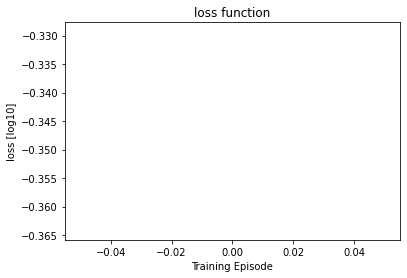

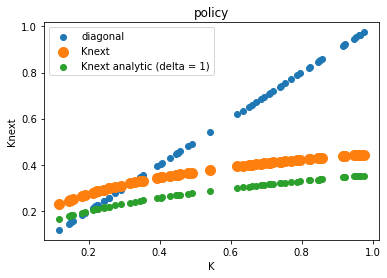

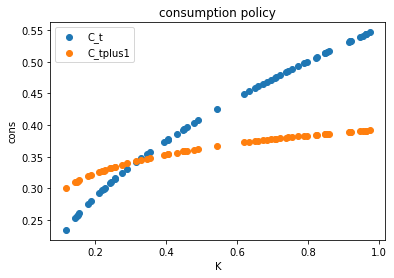

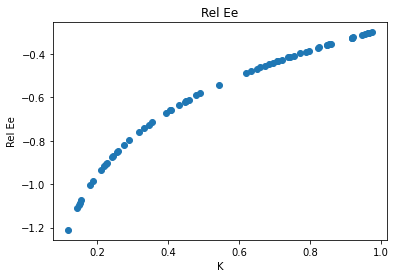

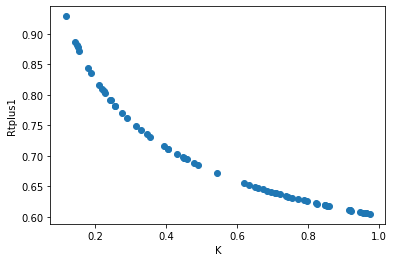

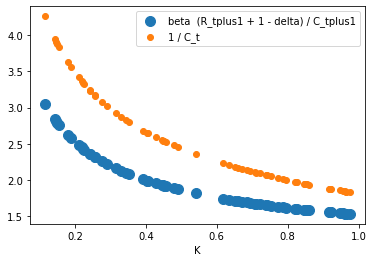

#=================================================================
episode = 100, loss [log10] = -1.833279013633728


#=================================================================
episode = 200, loss [log10] = -5.5353899002075195


#=================================================================
episode = 300, loss [log10] = -6.0537872314453125


#=================================================================
episode = 400, loss [log10] = -6.268707752227783


#=================================================================
episode = 500, loss [log10] = -6.25745964050293


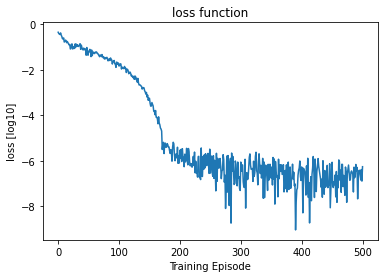

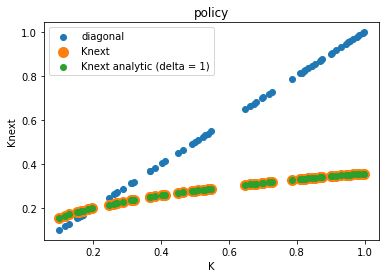

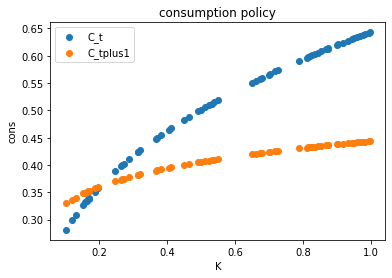

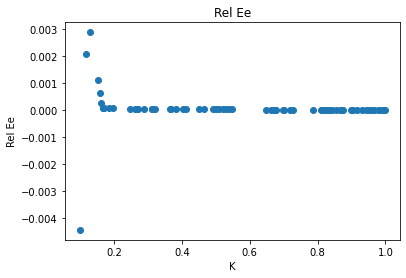

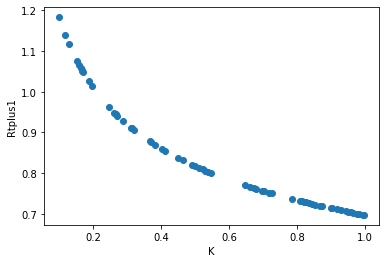

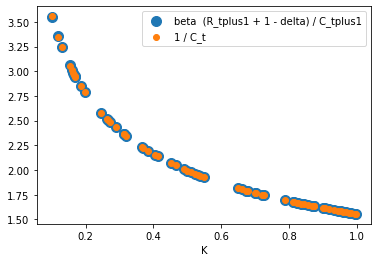

#=================================================================
episode = 600, loss [log10] = -6.563765048980713


#=================================================================
episode = 700, loss [log10] = -7.895870685577393


#=================================================================
episode = 800, loss [log10] = -7.621387004852295


#=================================================================
episode = 900, loss [log10] = -8.275641441345215


#=================================================================
episode = 1000, loss [log10] = -7.261270999908447


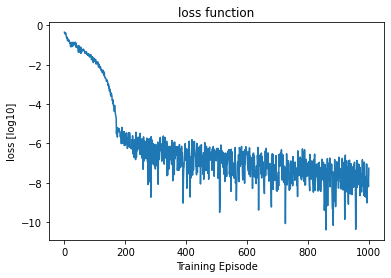

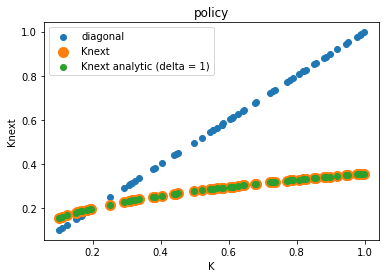

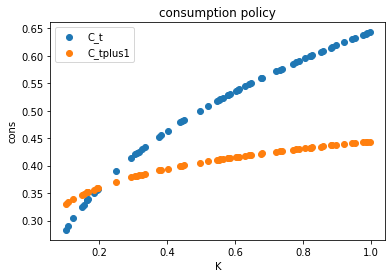

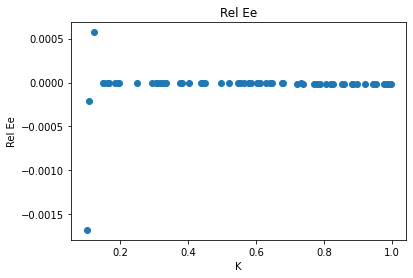

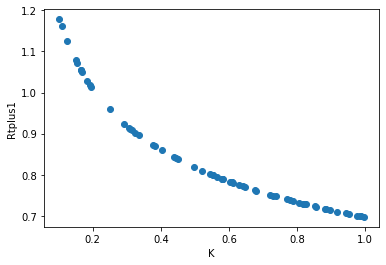

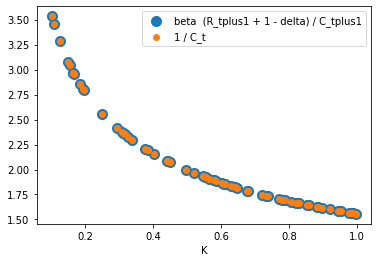

#=================================================================
episode = 1100, loss [log10] = -7.1427717208862305


#=================================================================
episode = 1200, loss [log10] = -8.71972370147705


#=================================================================
episode = 1300, loss [log10] = -8.39274787902832


#=================================================================
episode = 1400, loss [log10] = -8.43903923034668


#=================================================================
episode = 1500, loss [log10] = -7.519893646240234


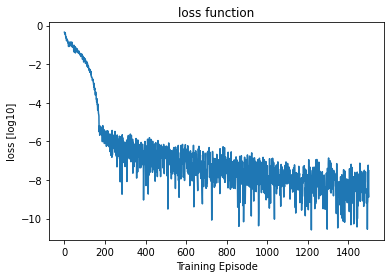

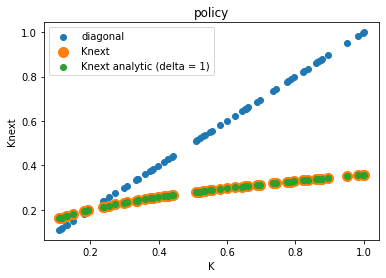

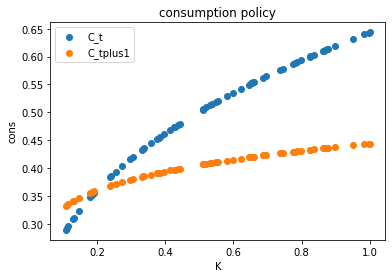

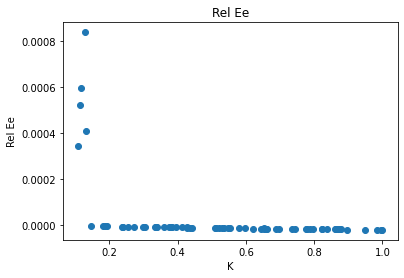

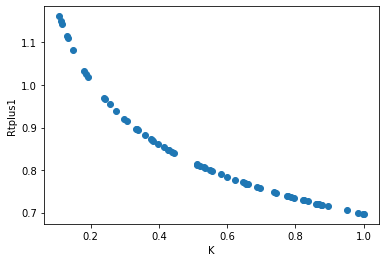

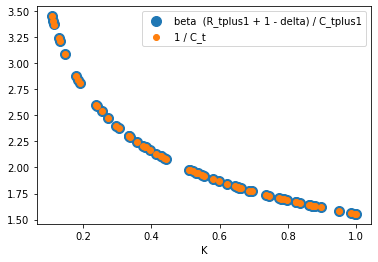

#=================================================================
episode = 1600, loss [log10] = -9.657485961914062


#=================================================================
episode = 1700, loss [log10] = -7.865766525268555


#=================================================================
episode = 1800, loss [log10] = -8.601480484008789


#=================================================================
episode = 1900, loss [log10] = -8.949310302734375


#=================================================================
episode = 2000, loss [log10] = -8.824063301086426


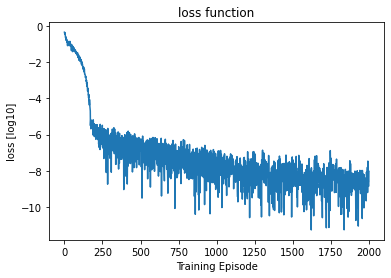

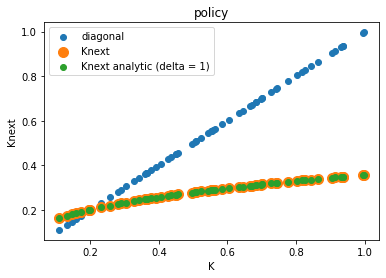

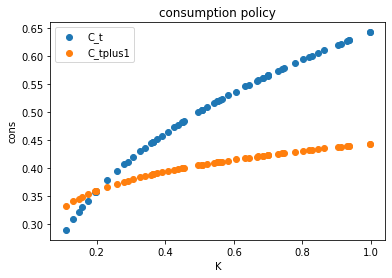

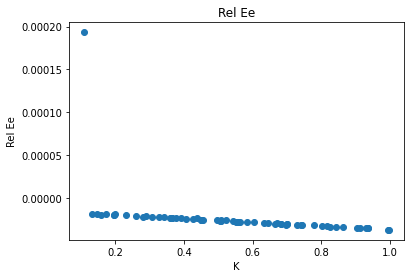

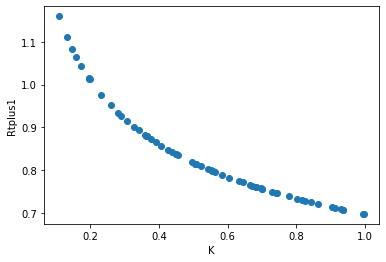

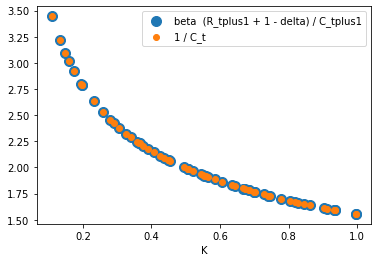

In [15]:
# Keep results for plotting
train_loss = []

num_episodes = NUM_EPISODES
n_data_per_epi = 64
k_lb = 0.10
k_ub = 1.0


for ep in range(num_episodes):
    # generate training data
    X = get_training_data(k_lb, k_ub, n_data_per_epi)

    # compute loss and gradients
    loss, grads = grad(X, nn)
    
    # apply gradients
    optimizer.apply_gradients(zip(grads, nn.trainable_variables))
    
    # record loss
    train_loss.append(loss.numpy())
    
    # print progress
    if ep % 100 == 0:
        print("#=================================================================")
        print("episode = {}, loss [log10] = {}".format(ep, np.log10(loss.numpy())))
        
    if ep % 500 == 0:
        cost, errREE, C_t, C_tplus1, K_tplus1, R_tplus1 = compute_cost(X, nn)
        
        plt.title("loss function")
        plt.plot(np.log10(np.array(train_loss)))
        plt.xlabel("Training Episode")
        plt.ylabel("loss [log10]")
        plt.show()
        plt.close()

        plt.title("policy")
        plt.xlabel("K")
        plt.ylabel("Knext")
        plt.scatter(X[:, 0], X[:, 0], label = "diagonal")
        plt.scatter(X[:, 0], K_tplus1[:, 0], s=100, label = "Knext")
        plt.scatter(X[:, 0], beta * alpha * X[:, 0] ** alpha, label = "Knext analytic (delta = 1)")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("consumption policy")
        plt.xlabel("K")
        plt.ylabel("cons")
        plt.scatter(X[:, 0], C_t[:, 0], label="C_t")
        plt.scatter(X[:, 0], C_tplus1[:, 0], label="C_tplus1")
        plt.legend()
        plt.show()
        plt.close()

        plt.title("Rel Ee")
        plt.xlabel("K")
        plt.ylabel("Rel Ee")
        plt.scatter(X[:, 0], errREE[:, 0], label="REE")
        plt.show()
        plt.close()
       
        plt.xlabel("K")
        plt.ylabel("Rtplus1")
        plt.scatter(X[:, 0], R_tplus1[:, 0], label="R_tplus1")
        plt.show()
        plt.close()

        plt.xlabel("K")
        plt.scatter(X[:, 0], beta * (R_tplus1[:, 0] + 1. - delta)/C_tplus1[:, 0], s=100, label="beta  (R_tplus1 + 1 - delta) / C_tplus1")
        plt.scatter(X[:, 0], 1/C_t[:, 0], label="1 / C_t")
        plt.legend()
        plt.show()
        plt.close()


## Cross-check 2: trained policy vs the analytical solution
With $\delta = 1$ the closed-form planner policy is $K_{t+1} = \alpha\beta\,K_t^{\alpha}$. We evaluate the trained network on a dense grid and report:

- the **policy curves** overlaid (NN vs analytical),
- the **absolute error** $|K^{\text{NN}}_{t+1} - \alpha\beta K_t^{\alpha}|$,
- the **relative error** $|K^{\text{NN}}_{t+1}/\alpha\beta K_t^{\alpha} - 1|$,
- summary statistics over the test grid.

Because the autodiff residual *is* the same Euler equation as in notebook 01, we expect the trained policy to match notebook 01's accuracy.

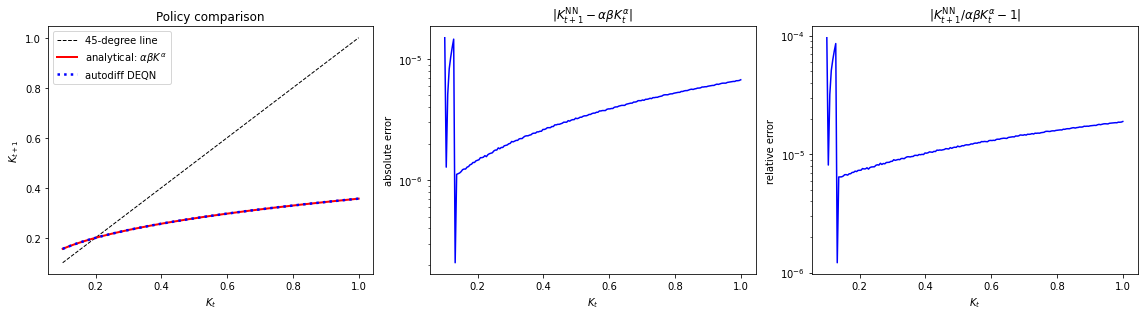

Comparison on a 200-point grid in [0.1, 1.0]:
  max  absolute error : 1.496e-05
  mean absolute error : 3.934e-06
  max  relative error : 9.616e-05
  mean relative error : 1.415e-05
  steady state K_inf  : 0.199482
  policy at K_inf     : NN -> 0.199489,  analytical -> 0.199487


In [16]:
# Analytical comparison
K_grid = tf.constant(np.linspace(k_lb, k_ub, 200).reshape(-1, 1), dtype=tf.float32)
s_grid = nn(K_grid).numpy().flatten()
K_grid_np = K_grid.numpy().flatten()
Y_grid = K_grid_np ** alpha
Kplus_nn = (1.0 - delta) * K_grid_np + Y_grid * s_grid
Kplus_an = Kplus_compute_analytic(K_grid_np, alpha, beta)

abs_err = np.abs(Kplus_nn - Kplus_an)
rel_err = abs_err / np.abs(Kplus_an)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(K_grid_np, K_grid_np, 'k--', lw=1, label='45-degree line')
axes[0].plot(K_grid_np, Kplus_an, 'r-', lw=2, label=r'analytical: $\alpha\beta K^{\alpha}$')
axes[0].plot(K_grid_np, Kplus_nn, 'b:', lw=2.5, label='autodiff DEQN')
axes[0].set_xlabel(r'$K_t$'); axes[0].set_ylabel(r'$K_{t+1}$')
axes[0].set_title('Policy comparison'); axes[0].legend()

axes[1].semilogy(K_grid_np, abs_err, 'b-')
axes[1].set_xlabel(r'$K_t$'); axes[1].set_ylabel('absolute error')
axes[1].set_title(r'$|K^{\rm NN}_{t+1} - \alpha\beta K_t^{\alpha}|$')

axes[2].semilogy(K_grid_np, rel_err, 'b-')
axes[2].set_xlabel(r'$K_t$'); axes[2].set_ylabel('relative error')
axes[2].set_title(r'$|K^{\rm NN}_{t+1} / \alpha\beta K_t^{\alpha} - 1|$')

plt.tight_layout(); plt.show()

print(f"Comparison on a 200-point grid in [{k_lb}, {k_ub}]:")
print(f"  max  absolute error : {abs_err.max():.3e}")
print(f"  mean absolute error : {abs_err.mean():.3e}")
print(f"  max  relative error : {rel_err.max():.3e}")
print(f"  mean relative error : {rel_err.mean():.3e}")
print(f"  steady state K_inf  : {k_infty:.6f}")
K_ss_idx = int(np.argmin(np.abs(K_grid_np - k_infty)))
print(f"  policy at K_inf     : NN -> {Kplus_nn[K_ss_idx]:.6f},  analytical -> {Kplus_an[K_ss_idx]:.6f}")


## Takeaway

- We replaced two pages of pen-and-paper algebra (FOC + envelope theorem) by **two `tf.GradientTape` calls** on a single primitive `Pi(K_in, K_out)`, where the two slots are the *state* and the *choice*.
- Cross-check 1 verified that the autodiff residual is the same number as the hand-derived one (machine precision).
- Cross-check 2 verified that the trained policy matches the closed-form analytical solution to comparable accuracy as notebook 01.
- The pattern generalizes: any model whose period payoff can be written as $\Pi(\text{state},\text{choice})$ admits an autodiff Euler residual of the form
$$\partial_2 \Pi + \beta\,\mathbb{E}[\partial_1 \Pi] = 0,$$
where $\partial_2\Pi$ is the derivative in the **choice slot** and $\partial_1\Pi$ is the derivative in the **state slot**. Notebook 03 applies exactly this template to the stochastic version with AR(1) productivity.